In [30]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


        



In [31]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, dropout=0.2):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, 
                           num_layers=num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)
        # Take the last time step
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

In [32]:
class TimeSeriesDataset(Dataset):
    def __init__(self, target_data, exog_data, seq_length):
        """
        Dataset for time series with optional exogenous variables.
        
        Args:
            target_data: Scaled target variable data
            exog_data: Scaled exogenous variables data (can be None)
            seq_length: Length of input sequences
        """
        self.target_data = target_data
        self.exog_data = exog_data
        self.seq_length = seq_length
        self.has_exog = exog_data is not None
    
    def __len__(self):
        return len(self.target_data) - self.seq_length
    
    def __getitem__(self, idx):
        # Target sequence and label
        target_seq = self.target_data[idx:idx+self.seq_length]
        y = self.target_data[idx+self.seq_length]
        
        if self.has_exog:
            # Combine target with exogenous variables
            exog_seq = self.exog_data[idx:idx+self.seq_length]
            # Stack target and exog features: shape (seq_length, 1 + n_exog)
            x = np.column_stack([target_seq.reshape(-1, 1), exog_seq])
        else:
            x = target_seq.reshape(-1, 1)
        
        return torch.FloatTensor(x), torch.FloatTensor([y])



In [33]:
def lstm_experiment(df, target, train_size=500, val_size=100, forecast_window=161, 
                   seq_length=30, epochs=100, batch_size=32, lr=0.001, dropout=0.2, hidden_size=32, num_layers=1,  exog=None, plot=False):
    """
    LSTM time series forecasting experiment
    """
    # Split data
    total_train_val = train_size + val_size
    train = df[target][-(total_train_val+forecast_window):-(val_size+forecast_window)].values
    val = df[target][-(val_size+forecast_window):-forecast_window].values
    test = df[target][-forecast_window:].values
    
    # Normalize data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.reshape(-1, 1)).flatten()
    val_scaled = scaler.transform(val.reshape(-1, 1)).flatten()

    exog_scaler = None
    exog_train_scaled = None
    exog_val_scaled = None
    exog_test_scaled = None
    
    if exog is not None:
        exog_train = df[exog][-(total_train_val+forecast_window):-(val_size+forecast_window)].values
        exog_val = df[exog][-(val_size+forecast_window):-forecast_window].values
        exog_test = df[exog][-forecast_window:].values
        exog_scaler = MinMaxScaler()
        exog_train_scaled = exog_scaler.fit_transform(exog_train)
        exog_val_scaled = exog_scaler.transform(exog_val)
        exog_test_scaled = exog_scaler.transform(exog_test)

    input_size = 1 + (len(exog) if exog else 0)
    
    # Create datasets
    train_dataset = TimeSeriesDataset(train_scaled, exog_train_scaled, seq_length)
    train_loader = DataLoader(train_dataset, batch_size=batch_size)
    
    val_dataset = TimeSeriesDataset(val_scaled, exog_val_scaled, seq_length)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Training loop
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader) if len(val_loader) > 0 else 0
        val_losses.append(avg_val_loss)
        
        if plot and (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
    
    # Forecasting
    model.eval()
    forecast = []
    
    # Use the last seq_length points from validation data as initial input for testing
    current_seq = val_scaled[-seq_length:].tolist()
    if exog is not None:
        current_exog_seq = exog_val_scaled[-seq_length:].tolist()
    
    with torch.no_grad():
        for step in range(forecast_window):
            # Prepare input
            if exog is not None:
                # Use known future exog values
                exog_future = exog_test_scaled[step]
                # Combine target sequence with exog
                current_seq_arr = np.array(current_seq).reshape(-1, 1)
                current_exog_arr = np.array(current_exog_seq)
                x = np.column_stack([current_seq_arr, current_exog_arr])
            else:
                x = np.array(current_seq).reshape(-1, 1)
            
            x = torch.FloatTensor(x).unsqueeze(0).to(device)
            
            # Predict next value
            pred = model(x).cpu().numpy()[0, 0]
            forecast.append(pred)
            
            # Update sequence (sliding window)
            current_seq = current_seq[1:] + [pred]
            if exog is not None:
                current_exog_seq = current_exog_seq[1:] + [exog_future.tolist()]
    
    # Inverse transform predictions
    forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1)).flatten()
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mae = mean_absolute_error(test, forecast)
    
    if plot:
        # Visualize results
        _, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
        
        # Plot forecast vs actual
        train_index = df[target][-(total_train_val+forecast_window):-(val_size+forecast_window)].index
        val_index = df[target][-(val_size+forecast_window):-forecast_window].index
        test_index = df[target][-forecast_window:].index
        
        ax1.plot(train_index, train, label='Train', alpha=0.7)
        ax1.plot(val_index, val, label='Validation', alpha=0.7, color='orange')
        ax1.plot(test_index, test, label='Actual Test', linewidth=2)
        ax1.plot(test_index, forecast, label='Forecast', linestyle='--', linewidth=2)
        ax1.legend()
        ax1.set_title('LSTM Forecast vs Actual')
        ax1.set_xlabel('Time')
        ax1.set_ylabel(target)
        ax1.grid(True, alpha=0.3)
        
        # Plot training loss
        ax2.plot(train_losses, label='Train Loss')
        ax2.plot(val_losses, label='Validation Loss')
        ax2.legend()
        ax2.set_title('Training and Validation Loss')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('MSE Loss')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    return model, scaler, exog_scaler, forecast, rmse, mae, test

In [ ]:
ITEM_ID = 26008           # Example item_id from sample_head.csv
STORE_ID = 6269        # Example store_id from sample_head.csv
DATA_PATH = '../dataset/data_andre.feather' # Adjust path if needed
TARGET_COL = 'value'
DATE_COL = 'date'
EPOCHS = 1000            # Increased epochs for better training
BATCH_SIZE = 32
LEARNING_RATE = 0.001
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
# -----------------------------------------------------------------------------
# DATA LOADING & PREPROCESSING
# -----------------------------------------------------------------------------
DATA_PATH = '../dataset/subset_set.feather'  # Adjust path if needed
print(f"Loading data from {DATA_PATH}...")
# Use pd.read_feather instead of feather.read_table to get a DataFrame directly
df_full = pd.read_feather(DATA_PATH)

print(f"Filtering for Item: {ITEM_ID}, Store: {STORE_ID}...")
# Filter for specific item and store
df = df_full[(df_full['item_id'] == ITEM_ID) & (df_full['store_id'] == STORE_ID)].copy()

# Reset index to avoid ambiguity if 'date' is also in the index
df = df.reset_index(drop=True)

# Ensure date is datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL)

# Prepare target variable
# Using 'value' as the target (sales/demand)
# Updated to use ffill() directly as fillna(method='ffill') is deprecated
y = df[TARGET_COL]

print(len(y))


# -----------------------------------------------------------------------------
# DATA SPLITTING
# -----------------------------------------------------------------------------
# Define split sizes
train_size = 500
val_size = 100
forecast_horizon = 161

lookback_window = 30

Loading data from ../dataset/subset_set.feather...
Filtering for Item: 26008, Store: 6269...
761


Training LSTM with train_size=500, val_size=100, forecast_window=161, seq_length=30...


c:\Users\Andre Silva\Desktop\Dissertation25-26\.venv\Lib\site-packages\torch\nn\modules\rnn.py:990: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


Epoch [10/1000], Train Loss: 0.010579, Val Loss: 0.003712
Epoch [20/1000], Train Loss: 0.009458, Val Loss: 0.003632
Epoch [30/1000], Train Loss: 0.008467, Val Loss: 0.003167
Epoch [40/1000], Train Loss: 0.008087, Val Loss: 0.003090
Epoch [50/1000], Train Loss: 0.007783, Val Loss: 0.003016
Epoch [60/1000], Train Loss: 0.007478, Val Loss: 0.002884
Epoch [70/1000], Train Loss: 0.008004, Val Loss: 0.002755
Epoch [80/1000], Train Loss: 0.007501, Val Loss: 0.002747
Epoch [90/1000], Train Loss: 0.007202, Val Loss: 0.002688
Epoch [100/1000], Train Loss: 0.007074, Val Loss: 0.002597
Epoch [110/1000], Train Loss: 0.006921, Val Loss: 0.002436
Epoch [120/1000], Train Loss: 0.006558, Val Loss: 0.002059
Epoch [130/1000], Train Loss: 0.006325, Val Loss: 0.001970
Epoch [140/1000], Train Loss: 0.006149, Val Loss: 0.001949
Epoch [150/1000], Train Loss: 0.005877, Val Loss: 0.001935
Epoch [160/1000], Train Loss: 0.006188, Val Loss: 0.002000
Epoch [170/1000], Train Loss: 0.005943, Val Loss: 0.001968
Epoch 

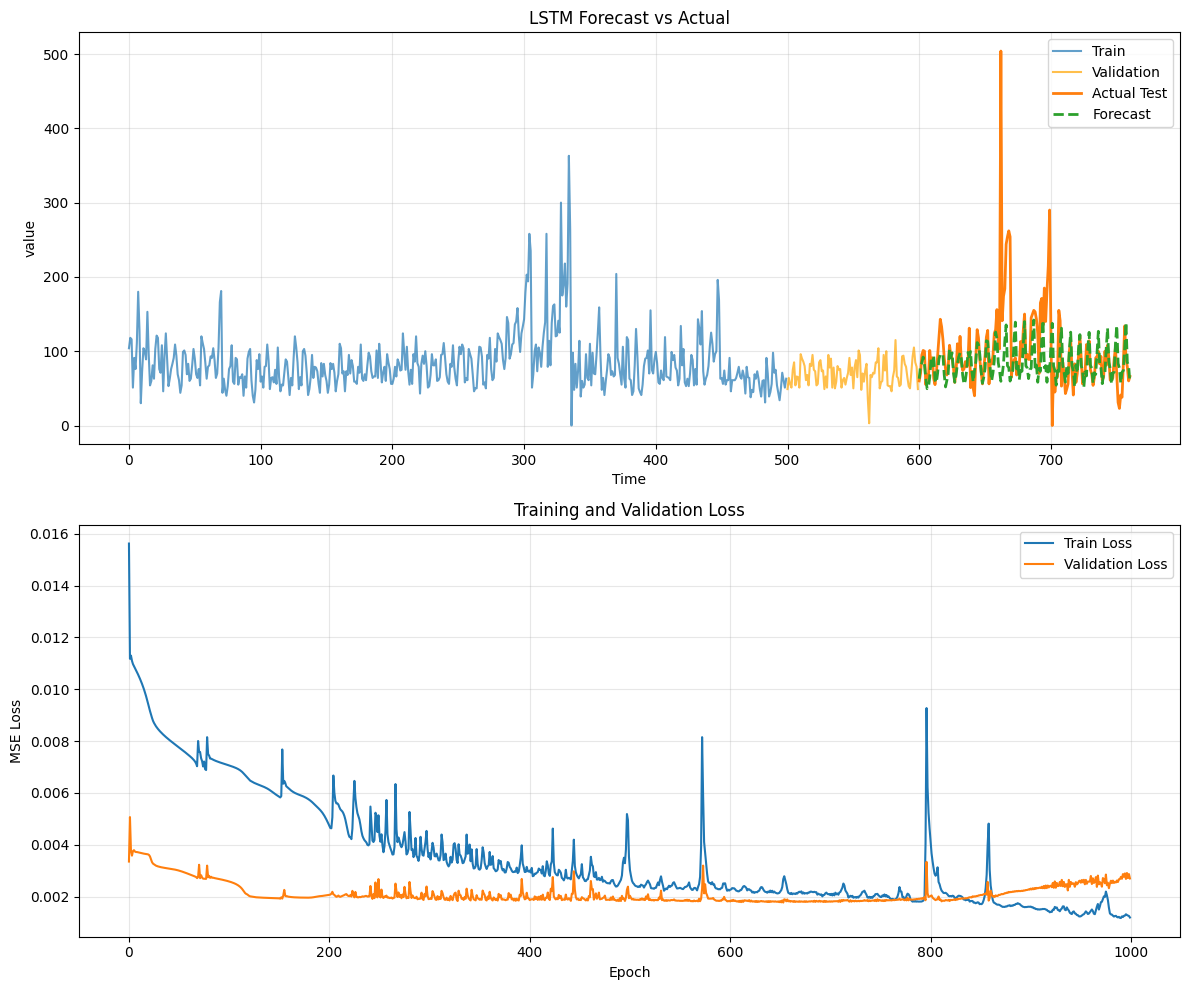

RMSE: 58.6419
MAE: 31.4446


In [ ]:
print(f"Training LSTM with train_size={train_size}, val_size={val_size}, forecast_horizon={forecast_horizon}, lookback_window={lookback_window}...")

model, scaler, exog_scaler, forecast, rmse, mae, test = lstm_experiment(
    df=df, 
    target=TARGET_COL, 
    train_size=train_size, 
    val_size=val_size,
    forecast_window=forecast_horizon, 
    seq_length=lookback_window, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    lr=LEARNING_RATE, 
    plot=True
)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")